In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram


BASE_DIR = Path(r"C:\Users\szymo\Desktop\Wibracje\Datasety\Wibracje wyważanie\processed")

TIME_COL = "Time_s"
ALL_COLS = ["Time_s", "ACXXX_SN1 [g]", "ACXXX_SN2 [g]", "Tacho_Ch8 [Hz]"]

SIGNAL_COLS = ["ACXXX_SN1 [g]", "ACXXX_SN2 [g]"]
TACHO_COL = "Tacho_Ch8 [Hz]"

F_MAX_HZ = 5000
F_MIN_HZ = 1

NPERSEG = 2**15

DATA_DIR = Path.cwd() / "Data"
DATA_DIR.mkdir(exist_ok=True)

CLEAR_DATA_DIR = True

PLOT_FIRST_ONLY = True
PRINT_FIRST_ONLY = True


In [2]:
def natural_key(path):
    return [int(x) if x.isdigit() else x.lower() for x in re.split(r"(\d+)", path.name)]


def parse_metadata(file_path):
    """
    Labelled examples:
        v01_14_a1_zew_processed.csv
        v01_14_a11_zew_sr_processed.csv

    Baseline example:
        v01_14_processed.csv

    Baseline files are treated as:
        angle = 0
        location = baseline
        imbalance = 0
    """

    labelled_pattern = re.compile(
        r"^v(?P<v_main>\d+)_(?P<v_sub>\d+)_a(?P<angle>\d+)_(?P<location>zew_sr|zew2|zew|sr)_processed\.csv$",
        re.IGNORECASE,
    )

    baseline_pattern = re.compile(
        r"^v(?P<v_main>\d+)_(?P<v_sub>\d+)_processed\.csv$",
        re.IGNORECASE,
    )

    match = labelled_pattern.match(file_path.name)

    if match:
        groups = match.groupdict()

        return {
            "filename": file_path.name,
            "stem": file_path.stem,
            "path": str(file_path),
            "v_main": int(groups["v_main"]),
            "v_sub": int(groups["v_sub"]),
            "angle": int(groups["angle"]),
            "location": groups["location"].lower(),
            "is_baseline": False,
            "source_pattern": "labelled",
        }

    match = baseline_pattern.match(file_path.name)

    if match:
        groups = match.groupdict()

        return {
            "filename": file_path.name,
            "stem": file_path.stem,
            "path": str(file_path),
            "v_main": int(groups["v_main"]),
            "v_sub": int(groups["v_sub"]),
            "angle": 0,
            "location": "baseline",
            "is_baseline": True,
            "source_pattern": "baseline_angle0_imbalance0",
        }

    return None


def infer_sampling_frequency(file_path):
    time = pd.read_csv(file_path, usecols=[TIME_COL])[TIME_COL]
    time = pd.to_numeric(time, errors="coerce").dropna().to_numpy()

    dt = np.diff(time)
    dt = dt[np.isfinite(dt) & (dt > 0)]

    if len(dt) == 0:
        raise ValueError(f"Cannot infer sampling frequency from {file_path.name}")

    return 1 / np.median(dt)


def read_data(file_path):
    df = pd.read_csv(file_path, usecols=ALL_COLS)

    for col in ALL_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def is_tacho_nonzero(df, col=TACHO_COL):
    x = df[col].to_numpy()
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return False

    return np.any(np.abs(x) > 0)


In [3]:
def get_complex_spectrogram(x, fs, nperseg=NPERSEG):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        raise ValueError("Signal is too short for spectrogram calculation.")

    nperseg = min(nperseg, len(x))
    noverlap = nperseg // 2

    f, t, Zxx = spectrogram(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="spectrum",
        mode="complex",
    )

    return f, t, Zxx


def complex_to_components(Zxx):
    amplitude_db = 20 * np.log10(np.abs(Zxx) + np.finfo(float).eps)

    phase_rad = np.angle(Zxx)
    phase_sin = np.sin(phase_rad)
    phase_cos = np.cos(phase_rad)

    return {
        "amplitude_db": amplitude_db.astype(np.float32),
        "phase_sin": phase_sin.astype(np.float32),
        "phase_cos": phase_cos.astype(np.float32),
    }


def process_channel(df, signal_col, fs, f_min_hz=F_MIN_HZ, f_max_hz=F_MAX_HZ):
    x = df[signal_col].to_numpy()

    f, t, Zxx = get_complex_spectrogram(x, fs)

    freq_mask = (f >= f_min_hz) & (f <= f_max_hz)

    f_plot = f[freq_mask].astype(np.float32)
    Z_plot = Zxx[freq_mask, :]

    components = complex_to_components(Z_plot)

    return f, t.astype(np.float32), f_plot, Z_plot, components


In [4]:
def plot_first_file_components(df, fs, file_path, f_min_hz=F_MIN_HZ, f_max_hz=F_MAX_HZ):
    """
    Plots SN1/SN2 only:
    rows = amplitude_db, phase_sin, phase_cos
    columns = SN1, SN2
    """

    fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True, sharey=True)

    for col_idx, signal_col in enumerate(SIGNAL_COLS):
        f, t, f_plot, Z_plot, components = process_channel(
            df,
            signal_col,
            fs,
            f_min_hz=f_min_hz,
            f_max_hz=f_max_hz,
        )

        rows = [
            ("amplitude_db", "Amplitude [dB]"),
            ("phase_sin", "sin(phase)"),
            ("phase_cos", "cos(phase)"),
        ]

        for row_idx, (component_key, label) in enumerate(rows):
            ax = axes[row_idx, col_idx]
            im = ax.pcolormesh(
                t,
                f_plot,
                components[component_key],
                shading="gouraud",
            )

            ax.set_title(f"{signal_col} | {component_key}")
            ax.set_yscale("log")
            ax.set_ylim(f_min_hz, f_max_hz)
            ax.set_ylabel("Frequency [Hz]")

            if row_idx == 2:
                ax.set_xlabel("Time [s]")

            fig.colorbar(im, ax=ax, label=label)

    fig.suptitle(file_path.name, fontsize=14)
    plt.tight_layout()
    plt.show()


def process_file(
    df,
    fs,
    file_path,
    f_max_hz=F_MAX_HZ,
    f_min_hz=F_MIN_HZ,
    plot=False,
    print_shapes=False,
):
    metadata = parse_metadata(file_path)

    if metadata is None:
        raise ValueError(f"Unsupported processed filename: {file_path.name}")

    channels_to_process = SIGNAL_COLS.copy()

    if is_tacho_nonzero(df):
        channels_to_process.append(TACHO_COL)
        metadata["tacho_saved"] = True
    else:
        metadata["tacho_saved"] = False

    saved_channels = {}

    f_plot_shared = None
    t_shared = None

    for signal_col in channels_to_process:
        f, t, f_plot, Z_plot, components = process_channel(
            df,
            signal_col,
            fs,
            f_min_hz=f_min_hz,
            f_max_hz=f_max_hz,
        )

        saved_channels[signal_col] = components

        if f_plot_shared is None:
            f_plot_shared = f_plot
            t_shared = t

        if print_shapes:
            print(file_path.name)
            print(signal_col)
            print("f", f.shape)
            print("t", t.shape)
            print("Z_plot", Z_plot.shape)
            for key, value in components.items():
                print(key, value.shape)
            print()

    payload = {
        "metadata": metadata,
        "fs": fs,
        "nperseg": NPERSEG,
        "f_min_hz": f_min_hz,
        "f_max_hz": f_max_hz,
        "frequency_hz": f_plot_shared,
        "time_s": t_shared,
        "channels": saved_channels,
        "phase_representation": "sin_cos",
    }

    out_name = (
        f"v{metadata['v_main']:02d}_{metadata['v_sub']:02d}"
        f"_a{metadata['angle']}_{metadata['location']}_spectrogram.npy"
    )

    out_path = DATA_DIR / out_name
    np.save(out_path, payload, allow_pickle=True)

    if plot:
        plot_first_file_components(
            df,
            fs,
            file_path,
            f_min_hz=f_min_hz,
            f_max_hz=f_max_hz,
        )

    return out_path


In [5]:
if CLEAR_DATA_DIR:
    old_files = sorted(DATA_DIR.glob("*.npy"), key=natural_key)

    for old_file in old_files:
        old_file.unlink()

    print(f"Cleared old .npy files from {DATA_DIR}: {len(old_files)} removed")


all_csv_files = sorted(BASE_DIR.glob("*.csv"), key=natural_key)

processed_files = []
ignored_files = []
unsupported_processed_files = []

for path in all_csv_files:
    if not path.name.endswith("_processed.csv"):
        ignored_files.append(path)
        continue

    metadata = parse_metadata(path)

    if metadata is None:
        unsupported_processed_files.append(path)
    else:
        processed_files.append(path)

if unsupported_processed_files:
    print("Unsupported processed files:")
    for path in unsupported_processed_files:
        print(" ", path.name)

    raise ValueError("Some *_processed.csv files do not match the supported filename patterns.")

print(f"CSV files found: {len(all_csv_files)}")
print(f"Processed CSV files used: {len(processed_files)}")
print(f"Ignored non-processed CSV files: {len(ignored_files)}")

if not processed_files:
    raise FileNotFoundError(f"No supported processed CSV files found in: {BASE_DIR}")

metadata_table = pd.DataFrame([parse_metadata(path) for path in processed_files])
display(metadata_table.head(20))

print("Angle counts:")
display(metadata_table["angle"].value_counts(dropna=False).sort_index())

print("Location counts:")
display(metadata_table["location"].value_counts(dropna=False).sort_index())


Cleared old .npy files from c:\Users\szymo\Desktop\Wibracje\Modele\Pipeline_Collected_Data\Data: 336 removed
CSV files found: 323
Processed CSV files used: 322
Ignored non-processed CSV files: 1


,filename,stem,path,v_main,v_sub,angle,location,is_baseline,source_pattern
0,v01_14_a1_sr_processed.csv,v01_14_a1_sr_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,1,sr,False,labelled
1,v01_14_a1_zew2_processed.csv,v01_14_a1_zew2_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,1,zew2,False,labelled
2,v01_14_a1_zew_processed.csv,v01_14_a1_zew_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,1,zew,False,labelled
3,v01_14_a3_sr_processed.csv,v01_14_a3_sr_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,3,sr,False,labelled
4,v01_14_a3_zew2_processed.csv,v01_14_a3_zew2_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,3,zew2,False,labelled
5,v01_14_a3_zew_processed.csv,v01_14_a3_zew_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,3,zew,False,labelled
6,v01_14_a5_sr_processed.csv,v01_14_a5_sr_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,5,sr,False,labelled
7,v01_14_a5_zew2_processed.csv,v01_14_a5_zew2_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,5,zew2,False,labelled
8,v01_14_a5_zew_processed.csv,v01_14_a5_zew_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,5,zew,False,labelled
9,v01_14_a7_sr_processed.csv,v01_14_a7_sr_processed,C:\Users\szymo\Desktop\Wibracje\Datasety\Wibra...,1,14,7,sr,False,labelled


Angle counts:


angle
0     14
1     42
3     42
5     42
7     42
11    56
13    42
15    42
Name: count, dtype: int64

Location counts:


location
baseline    14
sr          98
zew         98
zew2        98
zew_sr      14
Name: count, dtype: int64

Sampling frequency inferred from first file: 32768.000000 Hz
Saving .npy files to: c:\Users\szymo\Desktop\Wibracje\Modele\Pipeline_Collected_Data\Data
v01_14_a1_sr_processed.csv
ACXXX_SN1 [g]
f (16385,)
t (21,)
Z_plot (5000, 21)
amplitude_db (5000, 21)
phase_sin (5000, 21)
phase_cos (5000, 21)

v01_14_a1_sr_processed.csv
ACXXX_SN2 [g]
f (16385,)
t (21,)
Z_plot (5000, 21)
amplitude_db (5000, 21)
phase_sin (5000, 21)
phase_cos (5000, 21)



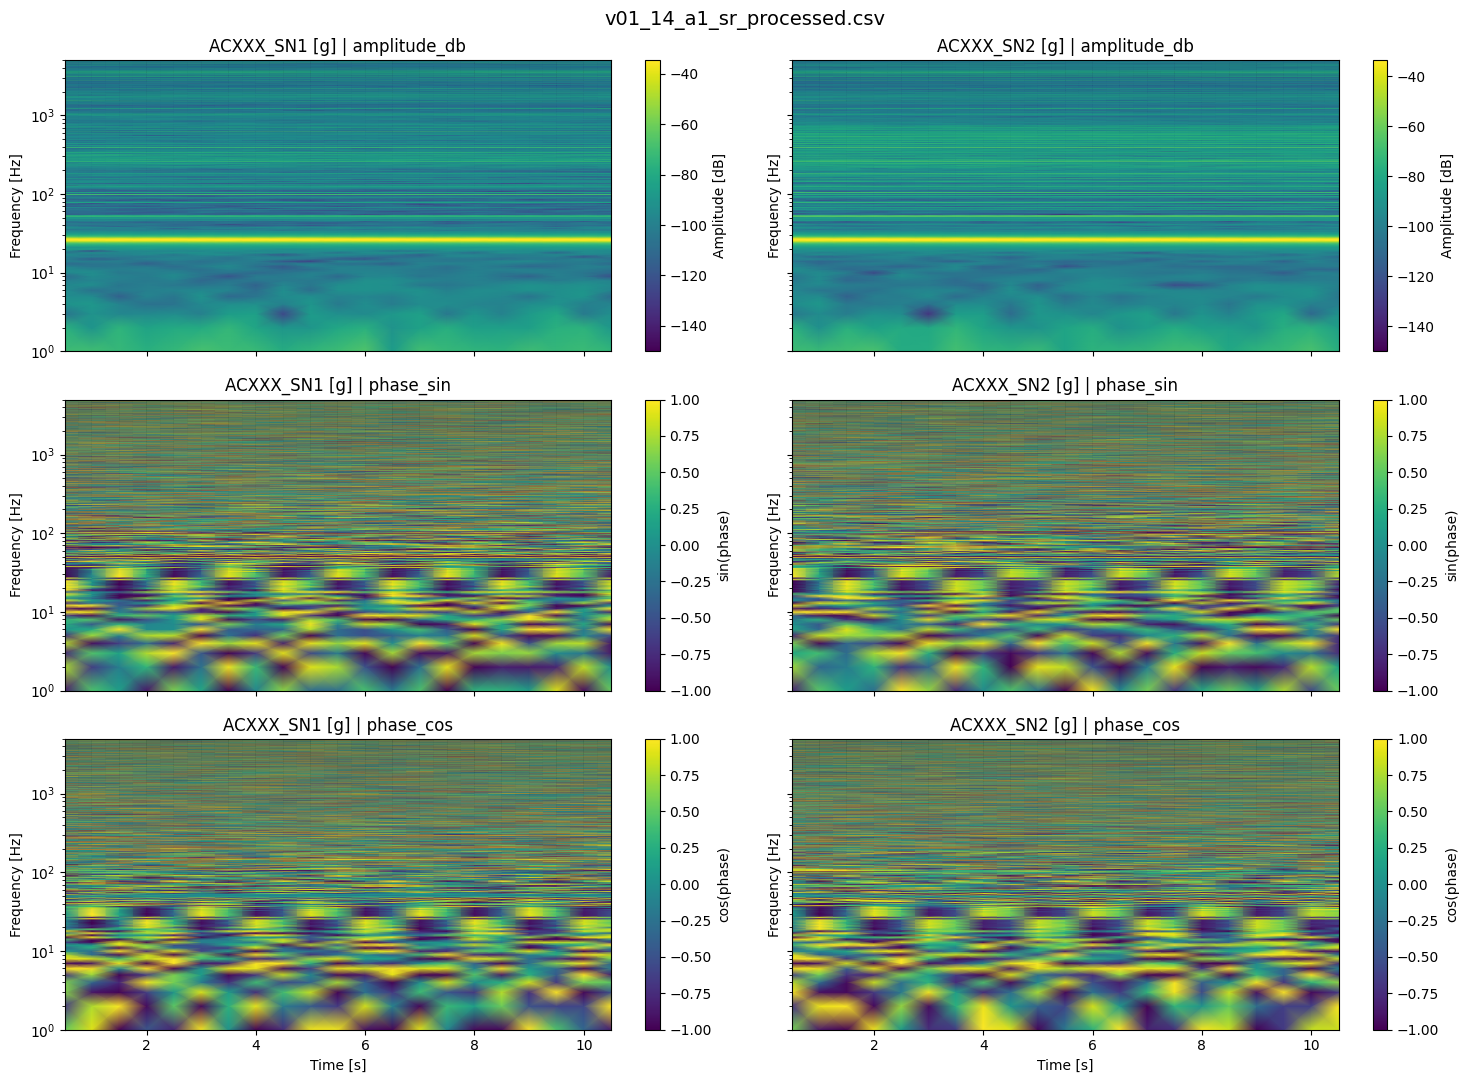

Saved 322 files.
First saved files:
v01_14_a1_sr_spectrogram.npy
v01_14_a1_zew2_spectrogram.npy
v01_14_a1_zew_spectrogram.npy
v01_14_a3_sr_spectrogram.npy
v01_14_a3_zew2_spectrogram.npy
v01_14_a3_zew_spectrogram.npy
v01_14_a5_sr_spectrogram.npy
v01_14_a5_zew2_spectrogram.npy
v01_14_a5_zew_spectrogram.npy
v01_14_a7_sr_spectrogram.npy


In [6]:
fs = infer_sampling_frequency(processed_files[0])

print(f"Sampling frequency inferred from first file: {fs:.6f} Hz")
print(f"Saving .npy files to: {DATA_DIR}")

saved_paths = []

for i, file_path in enumerate(processed_files):
    df = read_data(file_path)

    out_path = process_file(
        df=df,
        fs=fs,
        file_path=file_path,
        f_max_hz=F_MAX_HZ,
        f_min_hz=F_MIN_HZ,
        plot=(i == 0 and PLOT_FIRST_ONLY),
        print_shapes=(i == 0 and PRINT_FIRST_ONLY),
    )

    saved_paths.append(out_path)

print(f"Saved {len(saved_paths)} files.")
print("First saved files:")
for path in saved_paths[:10]:
    print(path.name)


In [7]:
loaded = np.load(saved_paths[0], allow_pickle=True).item()

print("Payload keys:", loaded.keys())
print("Phase representation:", loaded["phase_representation"])
print("Metadata:", loaded["metadata"])
print("Channels:", loaded["channels"].keys())

example_channel = next(iter(loaded["channels"].keys()))
print(example_channel, loaded["channels"][example_channel].keys())


Payload keys: dict_keys(['metadata', 'fs', 'nperseg', 'f_min_hz', 'f_max_hz', 'frequency_hz', 'time_s', 'channels', 'phase_representation'])
Phase representation: sin_cos
Metadata: {'filename': 'v01_14_a1_sr_processed.csv', 'stem': 'v01_14_a1_sr_processed', 'path': 'C:\\Users\\szymo\\Desktop\\Wibracje\\Datasety\\Wibracje wyważanie\\processed\\v01_14_a1_sr_processed.csv', 'v_main': 1, 'v_sub': 14, 'angle': 1, 'location': 'sr', 'is_baseline': False, 'source_pattern': 'labelled', 'tacho_saved': False}
Channels: dict_keys(['ACXXX_SN1 [g]', 'ACXXX_SN2 [g]'])
ACXXX_SN1 [g] dict_keys(['amplitude_db', 'phase_sin', 'phase_cos'])
